# QCTAR 2026 Hands-on session - 11th March 2026
## Quantum Gates, Quantum Circuits, and Quantum Algorithms with Qiskit

In this hands-on session, we will explore the basic building blocks of quantum computing using **Qiskit**.  
You will learn how to construct quantum circuits, apply quantum gates, and run simple quantum algorithms on a simulator.

Import Qiskit and check the version, for this session we prefer to use Qiskit version above 2.0. 

In [1]:
import qiskit
print(qiskit.version.get_version_info())

2.3.0


# Create a quantum circuit 
Let's now create a quantum circuit with 3 qubits and apply different **single-qubit gates** to illustrate key concepts such as **superposition, bit flips, and quantum rotations**.

This code imports the `QuantumCircuit` class from **Qiskit**, a Python library for quantum computing, and creates a quantum circuit (`qc`) with **three qubits**. We then apply three different **single-qubit gates**: a **Hadamard gate** `H` on qubit 0 to create superposition, a **Pauli-X gate** `X` on qubit 1 which flips the qubit state (similar to a classical NOT gate), and a **rotation gate** `Ry(π/2)` on qubit 2 that rotates the qubit state on the Bloch sphere.

Finally, the circuit is drawn using `Matplotlib` (`mpl`), giving a visual representation of the quantum gates applied to each qubit.

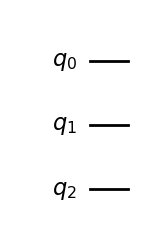

In [4]:
from qiskit import QuantumCircuit
import numpy as np
qc = QuantumCircuit(3)
qc.draw("mpl")

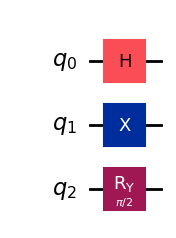

In [5]:
# Add a Hadamard gate (H), bit-flip (X) and a rotation gate R_y
qc.h(0)
qc.x(1)
qc.ry(np.pi/2, 2)
qc.draw("mpl")

### Initial state
The circuit starts in the computational basis state 
$|000⟩$
### After `qc.h(0)`

The Hadamard gate creates a **superposition** on qubit 0:

$\frac{1}{\sqrt{2}}(|000\rangle + |100\rangle)$

### After `qc.x(1)`

The Pauli-X gate flips **qubit 1** (0 → 1):

$\frac{1}{\sqrt{2}}(|010\rangle + |110\rangle)$

### After `qc.ry(\pi/2, 2)`

The rotation gate creates a **superposition on qubit 2**:

$ R_y(\pi/2)|0\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$

Applying this to the previous state gives

$
\frac{1}{2}(
|010\rangle +
|011\rangle +
|110\rangle +
|111\rangle
)
$

In [6]:
from qiskit.quantum_info import Statevector
# Get Statevector
state = Statevector.from_instruction(qc)
# print(state)
state.draw('latex')

<IPython.core.display.Latex object>

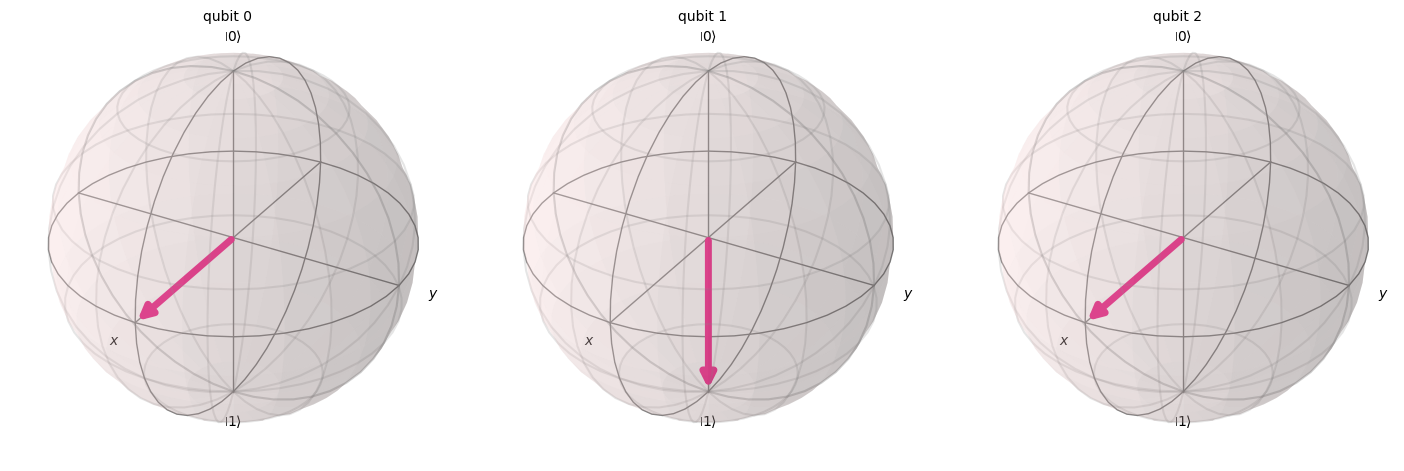

In [7]:
# Plot Bloch Sphere
from qiskit.visualization import plot_bloch_multivector
plot_bloch_multivector(state)

# Import more packages

Next, the `transpile` function is imported from `Qiskit`. Transpilation is the process of optimizing and transforming a quantum circuit to be compatible with a specific quantum device or simulator. This function helps in preparing the circuit for efficient execution on the selected backend.

Then, the `AerSimulator` is imported from `qiskit_aer`. The `AerSimulator` is a high-performance quantum circuit simulator provided by `Qiskit`. It allows users to simulate quantum circuits on a classical computer, making it possible to test and analyze circuits without needing access to an actual quantum device. This would be the local simulator during this course. We will only be running quantum circuits with less than 10 qubits. 

Lastly, the `plot_histogram` function is imported from `qiskit.visualization`. This function is used to visualize the results of quantum experiments, typically showing the probability distribution of measurement outcomes, which is valuable for interpreting the results of a quantum circuit.

In [8]:
# Import more packages
import numpy as np
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

This line creates an instance of the `AerSimulator`, which allows for simulating quantum circuits on a classical computer.

In [9]:
simulator = AerSimulator()

The `simulator.available_devices()` function lists all the devices available within the `AerSimulator` backend that can be used to simulate quantum circuits. Since you will be running on your laptop, this would be CPU. 

In [10]:
simulator.available_devices()

('CPU',)

The `simulator.available_methods()` function lists all the simulation methods supported by the `AerSimulator`, such as `statevector`, `density_matrix`, `stabilizer`, and `matrix_product_state`. Each method offers a different approach to simulating quantum circuits, with some optimized for specific types of circuits or computational needs. For the purpose of this course, we will only be using the `statevector` simulator. 

In [11]:
simulator.available_methods()

('automatic',
 'statevector',
 'density_matrix',
 'stabilizer',
 'matrix_product_state',
 'extended_stabilizer',
 'unitary',
 'superop')

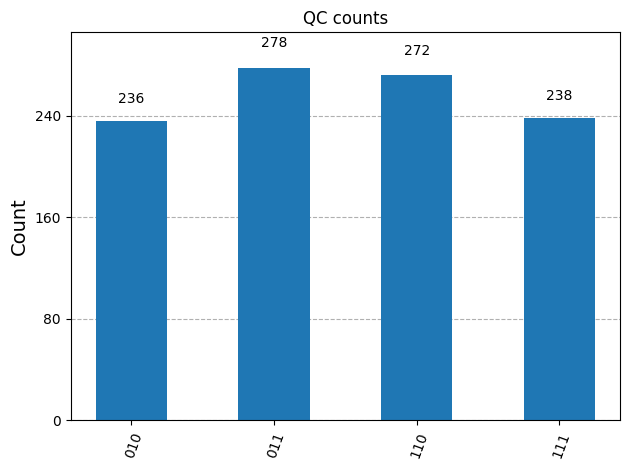

In [30]:
# Run and get counts
qc.measure_all()
simulator = AerSimulator()
result = simulator.run(qc).result()
counts = result.get_counts(qc)
plot_histogram(counts, title='QC counts')

# Create and run a Bell circuit in two qubits. 

In this section, we demonstrate how to set up a quantum circuit to create a Bell state:

$$
|\text{Bell}\rangle = \frac{1}{\sqrt{2}}(|00\rangle + |11\rangle)
$$

We use two qubits to generate this maximally entangled state by applying a Hadamard gate to the first qubit, followed by a CNOT gate with the first qubit as the control and the second as the target. Finally, we add measurement gates to both qubits to observe the entangled state.


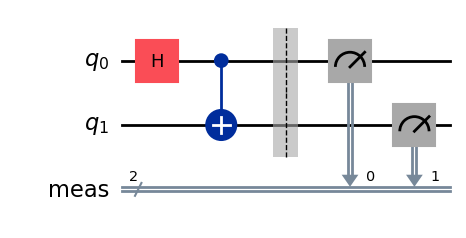

In [15]:
# Create circuit
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()
bell.draw("mpl")

This code executes the Bell circuit on the simulator and retrieves the results in the form of counts for each measurement outcome. The `plot_histogram` function is then used to visualize these counts, displaying the frequency of each possible result for the Bell state. This uses a defalut number of `shots=1--24`. One can change the shots by specifying the number of `shots` e.g., `shots=10000`.

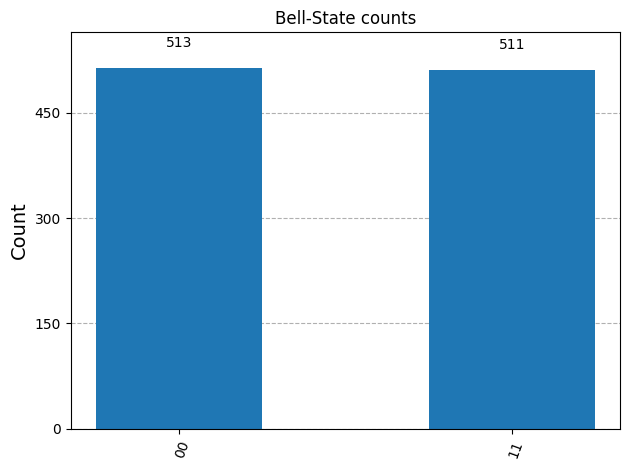

In [31]:
# Run and get counts
result = simulator.run(bell).result()
counts = result.get_counts(bell)
plot_histogram(counts, title='Bell-State counts')

This code runs the `bell` quantum circuit on the simulator for 10 shots while recording the quantum state memory after each execution. The results are retrieved using the `get_memory` method, which is then printed to show the sequence of outcomes from each shot of the simulation.

In [32]:
# Run and get memory
# increase shots
result = simulator.run(bell, shots=10, memory=True).result()
memory = result.get_memory(bell)
print(memory)

['11', '00', '11', '00', '00', '11', '00', '00', '00', '11']


# Decompose Option

Now, we will attempt to decompose the quantum circuit without transpilation, which can be beneficial for simplifying circuits, optimizing gate operations, or gaining insights into the underlying structure of quantum algorithms. As an example, we will use the Toffoli gate, a three-qubit gate that is not native but is part of the universal gate set.

Depth of the Toffoli circuit: 1


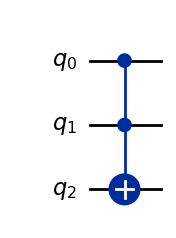

In [33]:
from qiskit.circuit import QuantumCircuit
ccx_circ = QuantumCircuit(3)
ccx_circ.ccx(0, 1, 2)
print("Depth of the Toffoli circuit:", ccx_circ.depth())
ccx_circ.draw(output='mpl')

We utilize the `QuantumCircuit.decompose()` method to break down this three-qubit circuit. This operation decomposes the three qubit Toffoi gate to 1- and 2-qubit gates.

Depth of the Toffoli circuit after decomposition: 11


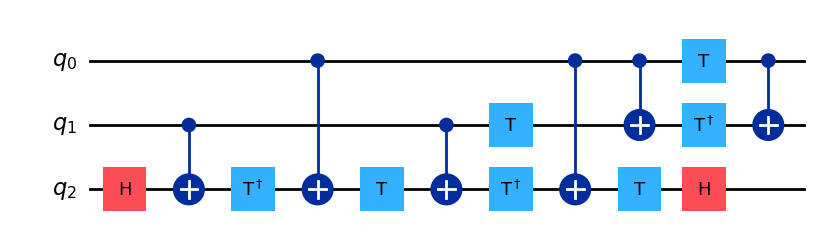

In [34]:
print("Depth of the Toffoli circuit after decomposition:", ccx_circ.decompose().depth())
ccx_circ.decompose().draw(output='mpl')

# Hadamard test

The **Hadamard test** is a simple quantum algorithm used to estimate the **expectation value of a unitary operator**.  
It is commonly used in quantum algorithms to measure quantities such as matrix elements or overlaps between quantum states.

The idea is to introduce an **ancilla qubit** that controls the application of a unitary operator \(U\). By preparing the ancilla in a superposition with a Hadamard gate and measuring it after the controlled operation, we can extract information about the **real part of the expectation value**:

$\langle \psi | U | \psi \rangle$

The probability of measuring the ancilla in state \(|0\rangle\) is related to this expectation value.

Steps of the Hadamard test:

1. Prepare an **ancilla qubit** in \(|0\rangle\).
2. Apply a **Hadamard gate** to create superposition.
3. Apply a **controlled-U** operation on the system state \(|\psi\rangle\).
4. Apply another **Hadamard gate** to the ancilla.
5. Measure the ancilla qubit.

From the measurement statistics, we can estimate the expectation value.

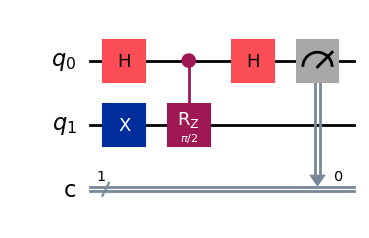

In [37]:
## Qiskit Implementation

# Create circuit: 1 ancilla + 1 system qubit
h_test = QuantumCircuit(2,1)

# # Prepare system state |psi>
h_test.x(1)

# Step 1: Hadamard on ancilla
h_test.h(0)

# Step 2: Controlled-U (here U = Z)
h_test.crz(np.pi/2,0,1)

# Step 3: Second Hadamard on ancilla
h_test.h(0)

# Measure ancilla
h_test.measure(0,0)

h_test.draw("mpl")

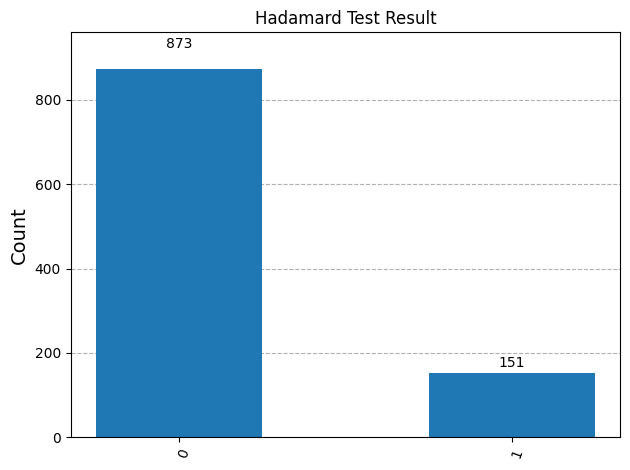

In [38]:
simulator = AerSimulator()
h_test_transpiled = transpile(h_test, simulator)

h_test_result = simulator.run(h_test_transpiled, shots=1024).result()
h_test_counts = h_test_result.get_counts()

plot_histogram(h_test_counts, title="Hadamard Test Result")

## Hadamard Test with a Controlled-$R_z(\theta)$ Gate

We observed the following measurement results from 1024 shots:

| Outcome | Counts | Observed Prob. | Theoretical Prob. |
|--------|--------|---------------|-------------------|
| 0 | 875 | ≈ 0.8545 | 0.8535 |
| 1 | 149 | ≈ 0.1455 | 0.1465 |

The theoretical probability comes from the expression

$P(0) = \cos^2\left(\frac{\theta}{4}\right)$

Below is the derivation.

---

### 1. Initial State

The circuit begins with

- **Ancilla qubit** prepared in a superposition using a Hadamard gate
- **Target qubit** in the state $(|0\rangle)$

The ancilla state is

$|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$

The joint state of ancilla and target is therefore

$
|\psi\rangle =
\frac{1}{\sqrt{2}}
\left(
|0\rangle_{anc}|0\rangle_{targ}
+
|1\rangle_{anc}|0\rangle_{targ}
\right)
$

---

### 2. Applying the Controlled-$R_z(\theta)$ Gate

The definition of the $R_z(\theta)$ gate is

$
R_z(\theta) =
\begin{pmatrix}
e^{-i\theta/2} & 0 \\
0 & e^{i\theta/2}
\end{pmatrix}
$

Acting on $(|0\rangle)$:

$R_z(\theta)|0\rangle = e^{-i\theta/2}|0\rangle$

Because the gate is **controlled**, the rotation only occurs when the ancilla is $(|1\rangle)$.

After the controlled operation, the joint state becomes

$
|\psi\rangle =
\frac{1}{\sqrt{2}}
\left(
|0\rangle_{anc}|0\rangle_{targ}
+
|1\rangle_{anc}(e^{-i\theta/2}|0\rangle_{targ})
\right)
$

Since the target state is still $(|0\rangle)$, we can factor it out:

$
|\psi_{anc}\rangle =
\frac{1}{\sqrt{2}}
\left(
|0\rangle + e^{-i\theta/2}|1\rangle
\right)
$

At this point the **phase has kicked back onto the ancilla**.

---

### 3. Applying the Second Hadamard

The Hadamard transforms the computational basis states as

$|0\rangle \rightarrow\frac{|0\rangle + |1\rangle}{\sqrt{2}}$ and $|1\rangle \rightarrow\frac{|0\rangle - |1\rangle}{\sqrt{2}}$

Apply this to the ancilla state:

$
H|\psi_{anc}\rangle =
\frac{1}{\sqrt{2}}
\left(
\frac{|0\rangle + |1\rangle}{\sqrt{2}}
+
e^{-i\theta/2}
\frac{|0\rangle - |1\rangle}{\sqrt{2}}
\right)
$

---

### 4. Group the Measurement Terms

Collect the coefficients of $(|0\rangle)$ and $(|1\rangle)$:

$
H|\psi_{anc}\rangle =
\frac{1}{2}
(1 + e^{-i\theta/2})|0\rangle
+
\frac{1}{2}
(1 - e^{-i\theta/2})|1\rangle
$

---

### 5. Measurement Probability

The probability of measuring **0** is the squared magnitude of its amplitude:

$
P(0) =
\left|
\frac{1 + e^{-i\theta/2}}{2}
\right|^2
$

---

### 6. Simplifying the Expression

Use the identity

$
1 + e^{ix} =
e^{ix/2}(e^{-ix/2} + e^{ix/2})
=
2e^{ix/2}\cos(x/2)
$

Applying this to our expression gives

$
\frac{1 + e^{-i\theta/2}}{2}
=
e^{-i\theta/4}
\cos\left(\frac{\theta}{4}\right)
$

Taking the magnitude squared (the phase factor has magnitude 1):

$
P(0) =
\cos^2\left(\frac{\theta}{4}\right)
$

---

### 7. Example: $\theta = \pi/2$

For our circuit $\theta = \frac{\pi}{2}$ so $\frac{\theta}{4} = \frac{\pi}{8}$

$
P(0) =
\cos^2\left(\frac{\pi}{8}\right)
\approx 0.8535
$

which matches the observed results:

| Outcome | Observed | Theory |
|--------|---------|--------|
| 0 | ≈ 0.8545 | 0.8535 |
| 1 | ≈ 0.1455 | 0.1465 |

---

### Key insight

The **controlled-$R_z$ gate introduces a phase**, and the second **Hadamard gate converts that phase into a measurable probability difference**.

This mechanism is exactly what allows quantum algorithms such as **quantum phase estimation** to extract phase information.

# Congratulations! You have reached the end of the hands-on session. 